# Fine-tuning DeepSeek-OCR


## 1. Cài đặt thư viện


In [1]:
%%capture
import os, re

# Cài đặt Unsloth và các thư viện bổ trợ
if "COLAB_" not in "".join(os.environ.keys()):
    !pip install unsloth
else:
    import torch; v = re.match(r"[0-9]{1,}\.[0-9]{1,}", str(torch.__version__)).group(0)
    xformers = "xformers==" + ("0.0.33.post1" if v=="2.9" else "0.0.32.post2" if v=="2.8" else "0.0.29.post3")
    !pip install --no-deps bitsandbytes accelerate {xformers} peft trl triton cut_cross_entropy unsloth_zoo
    !pip install sentencepiece protobuf "datasets==4.3.0" "huggingface_hub>=0.34.0" hf_transfer
    !pip install --no-deps unsloth

!pip install transformers==4.56.2
!pip install --no-deps trl==0.22.2
!pip install jiwer einops addict easydict
!pip uninstall -y tensorflow protobuf
!pip install -q tensorflow protobuf

In [2]:
import os

# Cấu hình môi trường
os.environ["UNSLOTH_WARN_UNINITIALIZED"] = '0'
os.environ["TOKENIZERS_PARALLELISM"] = "false"

# Seed cho reproducibility
SEED = 3407

print("✅ Môi trường đã được cấu hình!")


✅ Môi trường đã được cấu hình!


## 2. Load Model và LoRA


In [3]:
import torch
from unsloth import FastVisionModel
from transformers import AutoModel
from huggingface_hub import snapshot_download

# Đường dẫn lưu model
MODEL_DIR = "/kaggle/working/deepseek_ocr"

# Tải model nếu chưa có
if not os.path.exists(MODEL_DIR):
    print("⏳ Đang tải DeepSeek-OCR từ Hugging Face...")
    snapshot_download("unsloth/DeepSeek-OCR", local_dir=MODEL_DIR)

# Load model với 4-bit quantization cho GPU T4
print("🔄 Đang load model...")
model, tokenizer = FastVisionModel.from_pretrained(
    MODEL_DIR,
    load_in_4bit=True,
    auto_model=AutoModel,
    trust_remote_code=True,
    unsloth_force_compile=True,
    use_gradient_checkpointing="unsloth",
)

# Gắn LoRA adapter cho fine-tuning
model = FastVisionModel.get_peft_model(
    model,
    target_modules=[
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj",
    ],
    r=16,              # Rank của LoRA
    lora_alpha=16,     # Scaling factor
    lora_dropout=0,
    bias="none",
    random_state=SEED,
    use_rslora=False,
    loftq_config=None,
)

# Chuyển sang chế độ training
FastVisionModel.for_training(model)
print("✅ Model đã sẵn sàng cho fine-tuning!")


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
⏳ Đang tải DeepSeek-OCR từ Hugging Face...


.gitattributes: 0.00B [00:00, ?B/s]

README-checkpoint.md: 0.00B [00:00, ?B/s]

LICENSE: 0.00B [00:00, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

tokenizer_config.json: 0.00B [00:00, ?B/s]

You are using a model of type deepseek_vl_v2 to instantiate a model of type DeepseekOCR. This is not supported for all configurations of models and can yield errors.


🔄 Đang load model...
Unsloth: WARNING `trust_remote_code` is True.
Are you certain you want to do remote code execution?
==((====))==  Unsloth 2025.12.9: Fast Deepseekocr patching. Transformers: 4.56.2.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.741 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.8.0+cu126. CUDA: 7.5. CUDA Toolkit: 12.6. Triton: 3.4.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.32.post2. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


You are using a model of type deepseek_vl_v2 to instantiate a model of type DeepseekOCR. This is not supported for all configurations of models and can yield errors.
You are using a model of type deepseek_vl_v2 to instantiate a model of type DeepseekOCR. This is not supported for all configurations of models and can yield errors.
Some weights of DeepseekOCRForCausalLM were not initialized from the model checkpoint at /kaggle/working/deepseek_ocr and are newly initialized: ['model.vision_model.embeddings.position_ids']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Unsloth: Making `model.base_model.model.model` require gradients
✅ Model đã sẵn sàng cho fine-tuning!


## 3. Data Collator


In [4]:
import torch
import math
from dataclasses import dataclass
from typing import Dict, List, Any, Tuple
from PIL import Image, ImageOps
from torch.nn.utils.rnn import pad_sequence
import io
from deepseek_ocr.modeling_deepseekocr import text_encode, BasicImageTransform, dynamic_preprocess

@dataclass
class DeepSeekOCRDataCollator:
    tokenizer: Any
    model: Any
    image_size: int = 640
    base_size: int = 1024
    crop_mode: bool = True
    image_token_id: int = 128815
    train_on_responses_only: bool = True

    def __init__(self, tokenizer, model, image_size=640, base_size=1024, crop_mode=True, train_on_responses_only=True):
        self.tokenizer = tokenizer
        self.model = model
        self.image_size = image_size
        self.base_size = base_size
        self.crop_mode = crop_mode
        self.image_token_id = 128815
        self.dtype = model.dtype
        self.train_on_responses_only = train_on_responses_only
        self.image_transform = BasicImageTransform(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5), normalize=True)
        self.patch_size = 16
        self.downsample_ratio = 4
        self.bos_id = tokenizer.bos_token_id if hasattr(tokenizer, 'bos_token_id') else 0

    def deserialize_image(self, image_data) -> Image.Image:
        if isinstance(image_data, Image.Image): return image_data.convert("RGB")
        return Image.open(io.BytesIO(image_data['bytes'])).convert("RGB")

    def process_image(self, image: Image.Image):
        images_list, images_crop_list, images_spatial_crop = [], [], []
        if self.crop_mode:
            if image.size[0] <= 640 and image.size[1] <= 640:
                crop_ratio = (1, 1); images_crop_raw = []
            else:
                images_crop_raw, crop_ratio = dynamic_preprocess(image, min_num=2, max_num=9, image_size=self.image_size, use_thumbnail=False)
            global_view = ImageOps.pad(image, (self.base_size, self.base_size), color=tuple(int(x * 255) for x in self.image_transform.mean))
            images_list.append(self.image_transform(global_view).to(self.dtype))
            width_crop_num, height_crop_num = crop_ratio
            images_spatial_crop.append([width_crop_num, height_crop_num])
            if width_crop_num > 1 or height_crop_num > 1:
                for crop_img in images_crop_raw: images_crop_list.append(self.image_transform(crop_img).to(self.dtype))
            num_queries = math.ceil((self.image_size // self.patch_size) / self.downsample_ratio)
            num_queries_base = math.ceil((self.base_size // self.patch_size) / self.downsample_ratio)
            tokenized_image = ([self.image_token_id] * num_queries_base + [self.image_token_id]) * num_queries_base + [self.image_token_id]
            if width_crop_num > 1 or height_crop_num > 1:
                tokenized_image += ([self.image_token_id] * (num_queries * width_crop_num) + [self.image_token_id]) * (num_queries * height_crop_num)
        else:
            crop_ratio = (1, 1); images_spatial_crop.append([1, 1])
            if self.base_size <= 640:
                resized_image = image.resize((self.base_size, self.base_size), Image.LANCZOS)
                images_list.append(self.image_transform(resized_image).to(self.dtype))
            else:
                global_view = ImageOps.pad(image, (self.base_size, self.base_size), color=tuple(int(x * 255) for x in self.image_transform.mean))
                images_list.append(self.image_transform(global_view).to(self.dtype))
            num_queries = math.ceil((self.base_size // self.patch_size) / self.downsample_ratio)
            tokenized_image = ([self.image_token_id] * num_queries + [self.image_token_id]) * num_queries + [self.image_token_id]
        return images_list, images_crop_list, images_spatial_crop, tokenized_image, crop_ratio

    def process_single_sample(self, messages: List[Dict]):
        images = []
        for message in messages:
            if "image_path" in message:
                from PIL import Image
                img = Image.open(message["image_path"]).convert("RGB")
                images.append(img)
            elif "images" in message and message["images"]:
                for img_data in message["images"]:
                    images.append(self.deserialize_image(img_data))
        if not images: raise ValueError("No images found in sample")
        tokenized_str = [self.bos_id]; images_seq_mask = [False]; images_list, images_crop_list, images_spatial_crop = [], [], []; prompt_token_count = -1; assistant_started = False; image_idx = 0
        for message in messages:
            role, content = message["role"], message["content"]
            if role == "<|Assistant|>":
                if not assistant_started: prompt_token_count = len(tokenized_str); assistant_started = True
                content = f"{content.strip()} {self.tokenizer.eos_token}"
            text_splits = content.split('<image>')
            for i, text_sep in enumerate(text_splits):
                tokenized_sep = text_encode(self.tokenizer, text_sep, bos=False, eos=False)
                tokenized_str.extend(tokenized_sep); images_seq_mask.extend([False] * len(tokenized_sep))
                if i < len(text_splits) - 1:
                    if image_idx >= len(images): raise ValueError("Mismatch between <image> tokens and actual images")
                    img_list, crop_list, spatial_crop, tok_img, _ = self.process_image(images[image_idx])
                    images_list.extend(img_list); images_crop_list.extend(crop_list); images_spatial_crop.extend(spatial_crop)
                    tokenized_str.extend(tok_img); images_seq_mask.extend([True] * len(tok_img)); image_idx += 1
        if not assistant_started: prompt_token_count = len(tokenized_str)
        images_ori = torch.stack(images_list, dim=0)
        images_spatial_crop_tensor = torch.tensor(images_spatial_crop, dtype=torch.long)
        images_crop = torch.stack(images_crop_list) if images_crop_list else torch.zeros((1, 3, self.base_size, self.base_size), dtype=self.dtype)
        return {"input_ids": torch.tensor(tokenized_str, dtype=torch.long), "images_seq_mask": torch.tensor(images_seq_mask, dtype=torch.bool), "images_ori": images_ori, "images_crop": images_crop, "images_spatial_crop": images_spatial_crop_tensor, "prompt_token_count": prompt_token_count}

    def __call__(self, features: List[Dict[str, Any]]):
        batch_data = []
        for feature in features:
            try: batch_data.append(self.process_single_sample(feature['messages']))
            except Exception as e: print(f"Error: {e}"); continue
        if not batch_data: raise ValueError("No valid samples in batch")
        input_ids = pad_sequence([item['input_ids'] for item in batch_data], batch_first=True, padding_value=self.tokenizer.pad_token_id)
        images_seq_mask = pad_sequence([item['images_seq_mask'] for item in batch_data], batch_first=True, padding_value=False)
        prompt_token_counts = [item['prompt_token_count'] for item in batch_data]
        labels = input_ids.clone()
        labels[labels == self.tokenizer.pad_token_id] = -100
        labels[images_seq_mask] = -100
        if self.train_on_responses_only:
            for idx, prompt_count in enumerate(prompt_token_counts):
                if prompt_count > 0: labels[idx, :prompt_count] = -100
        attention_mask = (input_ids != self.tokenizer.pad_token_id).long()
        images_batch = [(item['images_crop'], item['images_ori']) for item in batch_data]
        images_spatial_crop = torch.cat([item['images_spatial_crop'] for item in batch_data], dim=0)
        return {"input_ids": input_ids, "attention_mask": attention_mask, "labels": labels, "images": images_batch, "images_seq_mask": images_seq_mask, "images_spatial_crop": images_spatial_crop}

## 4. Load Dataset


In [5]:
import random
import os
import json
import unicodedata

TRAIN_DATA_ROOT = "/kaggle/input/uit-uwdb-line/UIT_HWDB_line/train_data"

def load_dataset_from_folders(data_root):
    print(f"📂 Đang quét dữ liệu từ: {data_root}")
    dataset = []
    instruction = "<image>\nFree OCR. "
    
    if not os.path.exists(data_root):
        print(f"❌ Không tìm thấy folder: {data_root}")
        return []

    # Lấy danh sách folder con
    try:
        subfolders = sorted([f for f in os.listdir(data_root) if os.path.isdir(os.path.join(data_root, f))],
                          key=lambda x: int(x) if x.isdigit() else x)
    except:
        subfolders = sorted([f for f in os.listdir(data_root) if os.path.isdir(os.path.join(data_root, f))])

    for folder_name in subfolders:
        folder_path = os.path.join(data_root, folder_name)
        label_file = os.path.join(folder_path, "label.json")
        
        if not os.path.exists(label_file):
            continue

        try:
            with open(label_file, 'r', encoding='utf-8') as f:
                labels = json.load(f)
            
            for img_name, text in labels.items():
                img_path = os.path.join(folder_path, img_name)
                if os.path.exists(img_path):
                    if text:
                        text = unicodedata.normalize('NFC', text)
                    
                    dataset.append({
                        "messages": [
                            {
                                "role": "<|User|>", 
                                "content": instruction, 
                                "image_path": img_path 
                            },
                            {"role": "<|Assistant|>", "content": text}
                        ]
                    })
        except Exception:
            continue
            
    print(f"✅ Đã load {len(dataset)} mẫu (đường dẫn ảnh)")
    return dataset

# Thực hiện load và chia tập
full_data = load_dataset_from_folders(TRAIN_DATA_ROOT)
random.seed(3407)
random.shuffle(full_data)

val_size = int(len(full_data) * 0.1)
train_dataset = full_data[val_size:]
val_dataset = full_data[:val_size]

print(f"📊 Kết quả: Train ({len(train_dataset)}) - Val ({len(val_dataset)})")

📂 Đang quét dữ liệu từ: /kaggle/input/uit-uwdb-line/UIT_HWDB_line/train_data
✅ Đã load 7028 mẫu (đường dẫn ảnh)
📊 Kết quả: Train (6326) - Val (702)


## 5. Cấu hình Training


In [6]:
import sys
import os
from transformers import Trainer, TrainingArguments
from unsloth import is_bf16_supported, FastVisionModel

os.environ["WANDB_DISABLED"] = "true"

FastVisionModel.for_training(model)

data_collator = DeepSeekOCRDataCollator(
    tokenizer = tokenizer,
    model = model,
    image_size = 640,
    base_size = 1024,
    crop_mode = True,
    train_on_responses_only = True
)

training_args = TrainingArguments(
    output_dir = "/kaggle/working/deepseek_ocr_vietnamese_lora",
    per_device_train_batch_size = 2,
    per_device_eval_batch_size = 2,
    gradient_accumulation_steps = 8,
    warmup_steps = 10,
    num_train_epochs = 1,
    learning_rate = 1e-4,
    lr_scheduler_type = "linear",
    optim = "adamw_8bit",
    weight_decay = 0.001,
    logging_steps = 10,
    eval_strategy = "steps",
    eval_steps = 50,
    logging_first_step = True,
    
    seed = SEED,
    fp16 = not is_bf16_supported(),
    bf16 = is_bf16_supported(),
    save_strategy = "steps",
    save_steps = 50,
    save_total_limit = 1,
    load_best_model_at_end = True,
    
    dataloader_num_workers = 4,
    remove_unused_columns = False,
    report_to = "none",
)

trainer = Trainer(
    model = model,
    tokenizer = tokenizer,
    data_collator = data_collator,
    train_dataset = train_dataset,
    eval_dataset = val_dataset,
    args = training_args,
)

class CleanLog:
    def __init__(self, original_stdout):
        self.original_stdout = original_stdout
    def write(self, s):
        if any(x in s for x in ["BASE:", "PATCHES:", "torch.Size", "====", "Size(["]):
            return
        if s.strip() == "":
            return
        self.original_stdout.write(s)
    def flush(self):
        self.original_stdout.flush()

print(f"🚀 Trainer đã sẵn sàng!")
print(f"   - Thư mục đầu ra: {training_args.output_dir}")
print(f"   - Train/Val: {len(train_dataset)} / {len(val_dataset)}")

🚀 Trainer đã sẵn sàng!
   - Thư mục đầu ra: /kaggle/working/deepseek_ocr_vietnamese_lora
   - Train/Val: 6326 / 702


/tmp/ipykernel_24/2094214457.py:48: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer._unsloth___init__`. Use `processing_class` instead.
  trainer = Trainer(


## 6. Bắt đầu Training


In [7]:
# Bắt đầu training
print("🚀 Bắt đầu Fine-tuning...")
old_stdout = sys.stdout
sys.stdout = CleanLog(old_stdout)

try:
    train_result = trainer.train()
finally:
    sys.stdout = old_stdout

print("\n✅ Huấn luyện hoàn tất!")

🚀 Bắt đầu Fine-tuning...


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 6,326 | Num Epochs = 1 | Total steps = 198
O^O/ \_/ \    Batch size per device = 4 | Gradient accumulation steps = 8
\        /    Data Parallel GPUs = 1 | Total batch size (4 x 8 x 1) = 32
 "-____-"     Trainable parameters = 77,509,632 of 3,413,615,872 (2.27% trained)
Unsloth: Not an error, but DeepseekOCRForCausalLM does not accept `num_items_in_batch`.
Using gradient accumulation will be very slightly less accurate.
Read more on gradient accumulation issues here: https://unsloth.ai/blog/gradient


Unsloth: Will smartly offload gradients to save VRAM!

Step,Training Loss,Validation Loss
50,0.781800,0.768000
100,0.648900,0.645872
150,0.567800,0.590443


You are using a model of type deepseek_vl_v2 to instantiate a model of type DeepseekOCR. This is not supported for all configurations of models and can yield errors.
You are using a model of type deepseek_vl_v2 to instantiate a model of type DeepseekOCR. This is not supported for all configurations of models and can yield errors.
You are using a model of type deepseek_vl_v2 to instantiate a model of type DeepseekOCR. This is not supported for all configurations of models and can yield errors.
You are using a model of type deepseek_vl_v2 to instantiate a model of type DeepseekOCR. This is not supported for all configurations of models and can yield errors.



✅ Huấn luyện hoàn tất!


In [8]:
# Thống kê sau training
print("\n" + "="*50)
print("📊 KẾT QUẢ TRAINING")
print("="*50)
print(f"⏱️ Thời gian: {train_result.metrics['train_runtime']:.1f}s ({train_result.metrics['train_runtime']/60:.1f} phút)")
print(f"📉 Final Loss: {train_result.metrics['train_loss']:.4f}")


📊 KẾT QUẢ TRAINING
⏱️ Thời gian: 15067.3s (251.1 phút)
📉 Final Loss: 0.7333


## 7 Biểu đồ Loss quá trình training

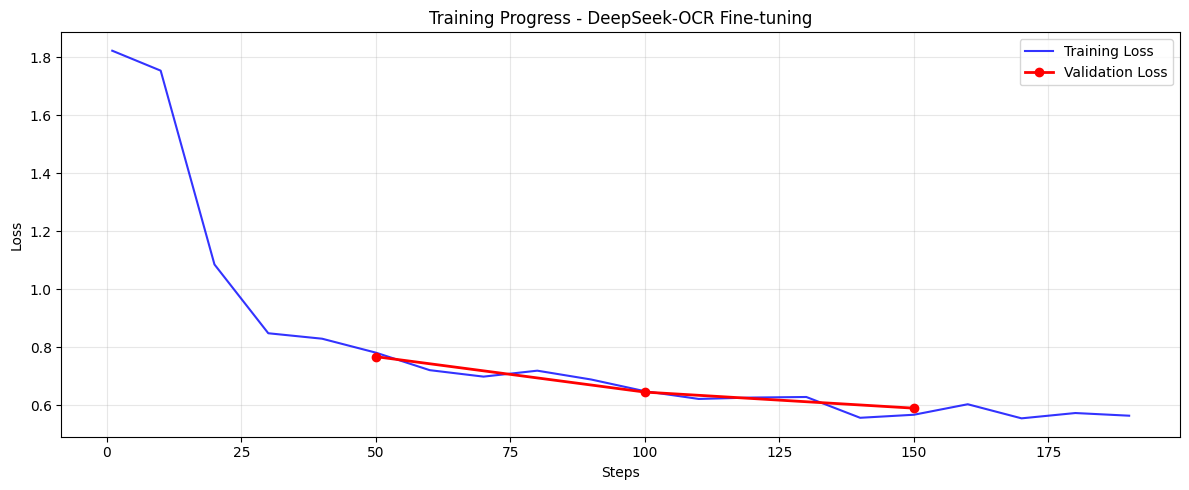

💾 Đã lưu biểu đồ: training_loss.png


In [9]:
import matplotlib.pyplot as plt

# Lấy log history
log_history = trainer.state.log_history

# Tách train và eval loss
train_steps = [x['step'] for x in log_history if 'loss' in x]
train_losses = [x['loss'] for x in log_history if 'loss' in x]
eval_steps = [x['step'] for x in log_history if 'eval_loss' in x]
eval_losses = [x['eval_loss'] for x in log_history if 'eval_loss' in x]

# Vẽ biểu đồ
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(train_steps, train_losses, 'b-', linewidth=1.5, label='Training Loss', alpha=0.8)
if eval_losses:
    ax.plot(eval_steps, eval_losses, 'r-o', linewidth=2, markersize=6, label='Validation Loss')

ax.set_xlabel('Steps')
ax.set_ylabel('Loss')
ax.set_title('Training Progress - DeepSeek-OCR Fine-tuning')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Lưu biểu đồ
fig.savefig('/kaggle/working/training_loss.png', dpi=150, bbox_inches='tight')
print("💾 Đã lưu biểu đồ: training_loss.png")


## 8. Lưu Model


In [10]:
# Lưu LoRA adapter
SAVE_PATH = "/kaggle/working/deepseek_ocr_vietnamese_lora"

model.save_pretrained(SAVE_PATH)
tokenizer.save_pretrained(SAVE_PATH)

print(f"✅ Đã lưu model fine-tuned tại: {SAVE_PATH}")


You are using a model of type deepseek_vl_v2 to instantiate a model of type DeepseekOCR. This is not supported for all configurations of models and can yield errors.


✅ Đã lưu model fine-tuned tại: /kaggle/working/deepseek_ocr_vietnamese_lora


In [11]:
# Nén model để dễ download
import shutil

zip_path = "/kaggle/working/deepseek_ocr_finetuned"
shutil.make_archive(zip_path, 'zip', SAVE_PATH)

print(f"📦 Đã nén model thành: {zip_path}.zip")


📦 Đã nén model thành: /kaggle/working/deepseek_ocr_finetuned.zip
